# imports

In [79]:
# Imports
import numpy as np
from numpy import nan
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
from scipy.spatial.distance import cdist
from tqdm.auto import tqdm
import seaborn as sns
import importlib
from scipy.stats import bernoulli
import warnings
from plotter import *
from scipy.special import softmax
from scipy.spatial.distance import cdist
import gymnasium as gym
from gymnasium.envs.registration import register, registry, make, spec
import pickle
import copy
from itertools import product
import json
from functools import partial
from scipy.optimize import Bounds, minimize, differential_evolution
import multiprocess as mp
from pybads import BADS
import pymer4.models as pm
import os
import IPython

import multiprocess as mp
import pingouin as pg
from scipy.special import expit

from emp_utils import *
from emp_runners import *
from plotter import *


warnings.filterwarnings('ignore')


%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [21]:
env = make_emp_env(n_arms=2, n_outcomes=3, n_trials=7, alpha=0.1, ell=1.0)
room_1 = [
    [1,0,0],
    [0,1,0]
    ]
room_2 = [
    [1,0,0],
    [0, 0.5,0.5],
    ]
ells = [0.5, 1.0, 2]
for ell in ells:
    for r, room in enumerate([room_1, room_2], start=1):
        print(f"Empowerment for ell={ell} in room {r}: {env.empowerment(room, ell)}")
    print('')

##

Empowerment for ell=0.5 in room 1: 2.0
Empowerment for ell=0.5 in room 2: 2.414213562373095

Empowerment for ell=1.0 in room 1: 2.0
Empowerment for ell=1.0 in room 2: 2.0

Empowerment for ell=2 in room 1: 2.0
Empowerment for ell=2 in room 2: 1.5



# Expts

## Interact with env

In [76]:
## make emp env
n_arms = 2
n_outcomes = 4
n_trials = 4
alpha = 0.1
ell = 1
policy = 'uniform_tail'
policy = 'bellman'
env = make_emp_env(n_arms, n_outcomes, n_trials, alpha, ell, seed = 1)

## make agent
agent = BAMCP(
    mcts_class=MonteCarloTreeSearch_Emp, run_fn=run_emp_bamcp,
    n_samples=100000,
    exploration_constant=3,
    discount_factor=1,
    horizon=1,
    temp=1,
    lapse=0,
)


run_emp_enum(agent, env, policy = policy)

NameError: name 'run_emp_enum' is not defined

## Enumerate histories

### Run

In [12]:
## inits
n_arms = 2
n_outcomes = 4
n_trials = 6
alpha = 0.1
temp = 0.1
ells = [0.1, 
        1.0, 
        10]

# run 
df = enumerate_emp_rows(
    n_arms=n_arms, n_outcomes=n_outcomes, n_trials=n_trials,
    alpha=alpha, termination_arm=True, ells=ells, temp=temp,
    n_jobs=1,
)
# save df
print(f"{len(df)} rows  ({len(ells)} ells x {len(df)//len(ells)} histories)")
df.loc[df['history_counts_str'].isna(), 'history_counts_str'] = '()'
df.to_csv('useful_saves/enum_histories_{}_arms_{}_outcomes_{}_trials_{}_alpha.csv'.format(n_arms, n_outcomes, n_trials, alpha), index=False)
display(df.head(70))

Running serially...
192 rows  (3 ells x 64 histories)


,ell,t,history,history_str,orbit_size,current_emp,p_choose_least_sampled,best_a,policy_entropy,chosen_prob,...,delta_emp_1,entropy_1,max_reach__0,max_reach__1,max_reach__2,max_reach__3,Q_terminate,p_terminate,history_counts,history_counts_str
0,0.1,0,(),init,1,3.482202,0.433071,1,0.994020,0.433071,...,0.105622,-20.090361,0.250000,0.250000,0.250000,0.250000,3.482202,0.133859,(),init
1,1.0,0,(),init,1,1.000000,0.499678,1,0.698080,0.499678,...,0.535714,-20.090361,0.250000,0.250000,0.250000,0.250000,1.000000,0.000645,(),init
2,10.0,0,(),init,1,0.000004,0.498810,1,0.708248,0.498810,...,0.089669,-20.090361,0.250000,0.250000,0.250000,0.250000,0.000004,0.002379,(),init
3,0.1,1,"(((0, 0), 1),)",a0o0:1,8,3.587824,0.137711,0,0.996985,0.456530,...,-0.151419,-20.090361,0.785714,0.250000,0.250000,0.250000,3.587824,0.405758,"(((0, 0), 1),)",a0o0:1
4,1.0,1,"(((0, 0), 1),)",a0o0:1,8,1.535714,0.439825,1,0.977348,0.439825,...,0.000000,-20.090361,0.785714,0.250000,0.250000,0.250000,1.535714,0.120350,"(((0, 0), 1),)",a0o0:1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
65,10.0,4,"(((0, 0), 2), ((0, 1), 1), ((1, 2), 1))",a0o0:2-a0o1:1-a1o2:1,576,0.097762,0.584044,1,0.896714,0.584044,...,0.117178,-21.114285,0.617647,0.323529,0.785714,0.071429,0.097762,0.090404,"(((0, 0), 2), ((0, 1), 1), ((1, 2), 1))",a0o0:2-a0o1:1-a1o2:1
66,0.1,4,"(((0, 0), 2), ((1, 0), 2))",a0o0:2-a1o0:2,24,3.169969,0.371881,1,1.084622,0.371881,...,0.024254,-23.135933,0.875000,0.041667,0.041667,0.041667,3.169969,0.256239,"(((0, 0), 2), ((1, 0), 2))",a0o0:2-a1o0:2
67,1.0,4,"(((0, 0), 2), ((1, 0), 2))",a0o0:2-a1o0:2,24,1.000000,0.421116,0,1.019741,0.421116,...,0.067402,-23.135933,0.875000,0.041667,0.041667,0.041667,1.000000,0.157768,"(((0, 0), 2), ((1, 0), 2))",a0o0:2-a1o0:2
68,10.0,4,"(((0, 0), 2), ((1, 0), 2))",a0o0:2-a1o0:2,24,0.263076,0.466645,0,0.891950,0.466645,...,0.117215,-23.135933,0.875000,0.041667,0.041667,0.041667,0.263076,0.066709,"(((0, 0), 2), ((1, 0), 2))",a0o0:2-a1o0:2


### Load

In [3]:
n_arms = 2
n_outcomes = 4
n_trials = 8
alpha = 0.1
temp = 0.1
ells = [0.1, 
        1.0, 
        10]

## load df
df = pd.read_csv('useful_saves/emp/enum_histories_{}_arms_{}_outcomes_{}_trials_{}_alpha.csv'.format(n_arms, n_outcomes, n_trials, alpha))

KeyboardInterrupt: 

### Plot histories

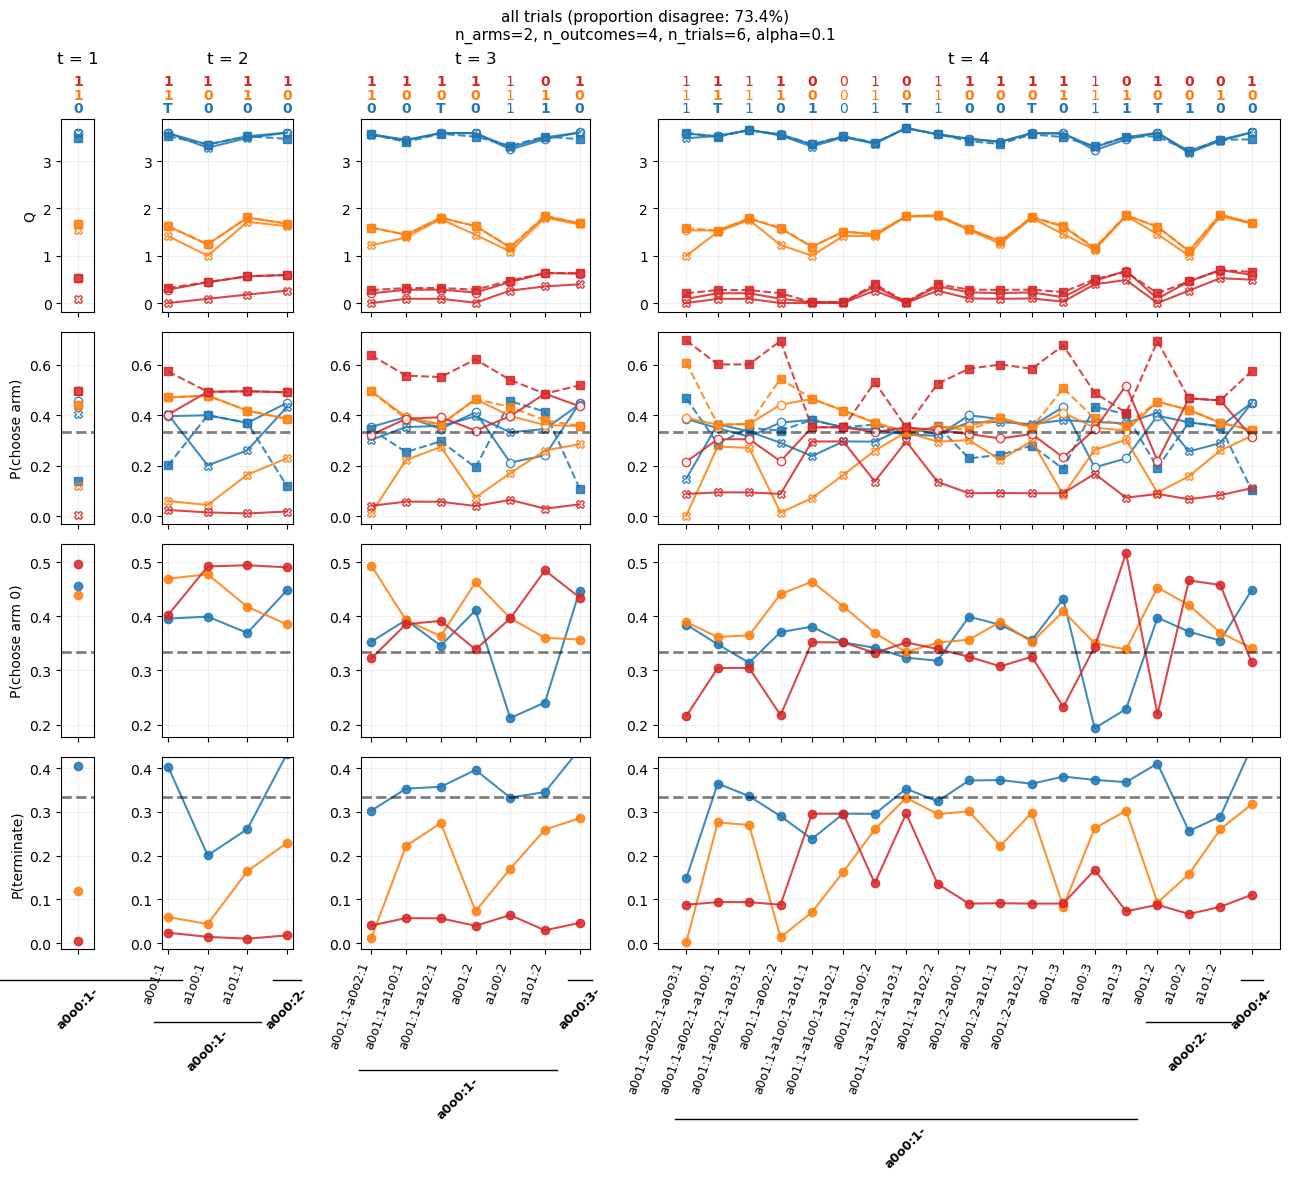

In [13]:
## preprocess: add 'history_canon_counts_str' and 'disagree' columns
df_cleaned = filter_histories(df, canonicalize=True)
disagree_only = False
proportion_disagree = df_cleaned.groupby(['t', 'history_canon_counts_str'])['disagree'].mean().mean()
if disagree_only:
    title = 'disagree trials (proportion of total: {:.1%})\nn_arms={}, n_outcomes={}, n_trials={}, alpha={}'.format(proportion_disagree, n_arms, n_outcomes, n_trials, alpha)
else:
    title = 'all trials (proportion disagree: {:.1%})\nn_arms={}, n_outcomes={}, n_trials={}, alpha={}'.format(proportion_disagree, n_arms, n_outcomes, n_trials, alpha)

## plot
plot_history_panels(
    df_cleaned,
    ells=ells,
    n_arms=n_arms,
    canonicalize=True,
    n_plot_trials=5,
    disagree_only=disagree_only,
    group_brackets=True,
    skip_t0=True,
    legend=False,
    suptitle=f'{title}',
)
plt.show()

### Entropy plots; termination prefs

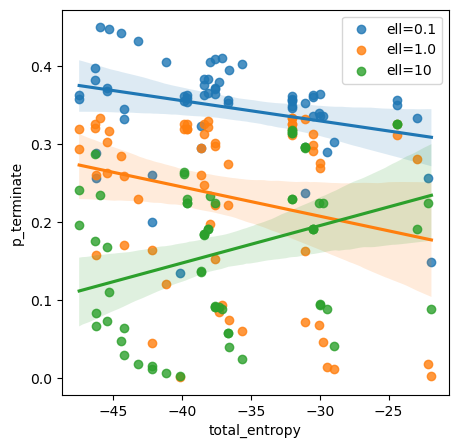

In [32]:
## entropy plots
plt.figure(figsize=(5,5))
for ell in ells:
    sns.regplot(
              # x='chosen_entropy', 
              #   y='chosen_prob',
              x='total_entropy', 
                y='p_terminate',
                  data=df_cleaned.loc[df_cleaned['ell'] == ell], label=f'ell={ell}')
plt.legend()



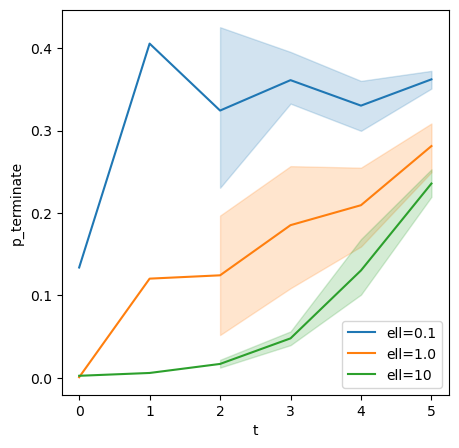

In [47]:
plt.figure(figsize=(5,5))
for ell in ells:
    sns.lineplot(data = df_cleaned.loc[df_cleaned['ell'] == ell], x='t', 
                 y='p_terminate', 
                #  y='p_choose_least_sampled', 
                 label=f'ell={ell}', palette = 'Set1')

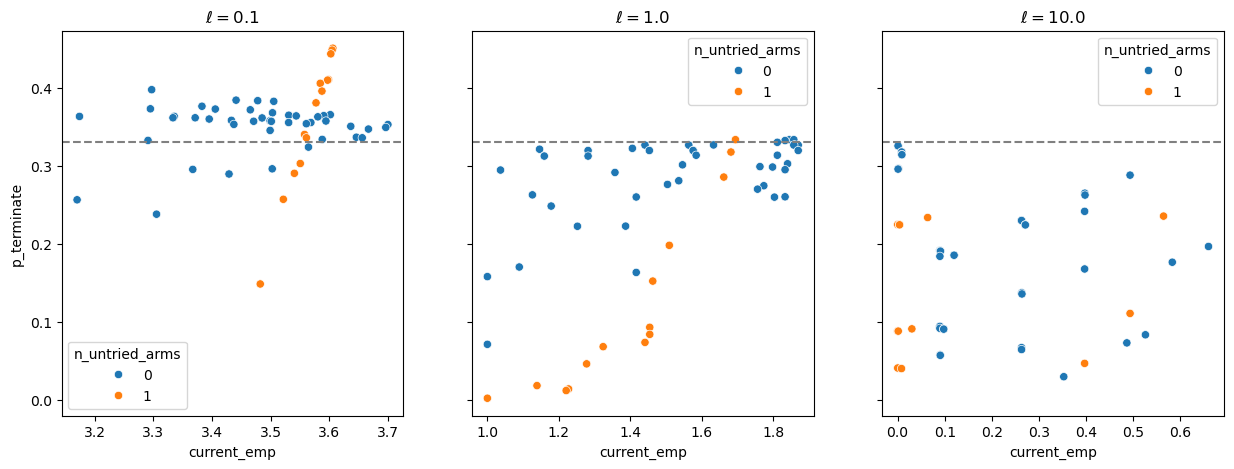

In [46]:
## analyse when each agent wants to terminate
fig, axs = plt.subplots(1, len(ells), figsize=(5*len(ells), 5), sharey=True)
for i, ell in enumerate(df_cleaned['ell'].unique()):
  tmp = df_cleaned.loc[(df_cleaned['ell']==ell) 
                &(df_cleaned['t']>=n_trials-3)
              #    &(df_cleaned['p_terminate']>0.33)
  ]
                # ,['t','history_canon_counts_str','canon_p_0','canon_p_1','p_terminate', 'current_emp', 'total_entropy']].groupby('history_canon_counts_str').first()

  ## order tmp by p_terminate
  tmp = tmp.sort_values('p_terminate', 
                        # ascending=True
                        ascending=False
                        )
  # display(tmp[
  #     ['t','history_canon_counts_str','best_a','canon_p_0','canon_p_1','p_terminate', 'p_choose_least_sampled','current_emp','max_delta_emp', 'total_entropy', 'n_untried_arms', 'n_unobserved_outcomes']
  # ].head(50))
  # print(len(tmp))

  ## scatter of current_emp and p_terminate
  hue = 'n_untried_arms'
  # hue = 'n_unobserved_outcomes'

  sns.scatterplot(data=tmp, 
                  x='current_emp', 
                  y='p_terminate',
                  # y='p_choose_least_sampled',

                  # style='n_untried_arms',
                  # hue = 'n_unobserved_outcomes',

                    hue = hue,
                    ax = axs[i]
                    )
  axs[i].axhline(0.33, color='gray', linestyle='--')
  axs[i].set_title(f'$\\ell={ell}$')

,t,history_canon_counts_str,canon_p_0,canon_p_1,p_terminate,p_choose_least_sampled,current_emp,max_delta_emp,total_entropy,n_untried_arms,n_unobserved_outcomes
334,6,a0o0:1-a0o1:4-a1o1:1,0.190950,0.636816,0.172234,0.636816,0.089670,0.130763,-39.011436,0,2
347,6,a0o0:1-a0o1:1-a0o2:3-a1o2:1,0.190382,0.619247,0.190371,0.619247,0.089670,0.117953,-31.060142,0,1
343,6,a0o0:1-a1o0:3-a1o1:2,0.618998,0.190698,0.190305,0.618998,0.089749,0.117947,-38.662247,0,2
374,6,a0o0:1-a0o1:1-a0o2:1-a0o3:2-a1o3:1,0.191266,0.617485,0.191249,0.617485,0.089670,0.117208,-23.195574,0,0
366,6,a0o0:1-a0o1:2-a0o2:2-a1o1:1,0.191583,0.617235,0.191183,0.617235,0.089749,0.117202,-30.797679,0,1
375,6,a0o0:1-a0o1:1-a0o2:1-a0o3:2-a1o0:1,0.191587,0.617231,0.191182,0.617231,0.089749,0.117202,-23.195574,0,0
367,6,a0o0:1-a0o1:2-a0o2:2-a1o0:1,0.191904,0.616981,0.191115,0.616981,0.089828,0.117196,-30.797679,0,1
368,6,a0o0:1-a0o1:2-a0o2:2-a1o3:1,0.191909,0.616977,0.191114,0.616977,0.089828,0.117196,-30.797679,0,0
331,6,a0o0:1-a1o1:5,0.584983,0.233781,0.181236,0.584983,0.654300,0.117178,-47.005726,0,2
335,6,a0o0:1-a0o1:4-a1o0:1,0.219885,0.595592,0.184523,0.595592,0.153335,0.117178,-39.011436,0,2


68


<Axes: xlabel='current_emp', ylabel='max_delta_emp'>

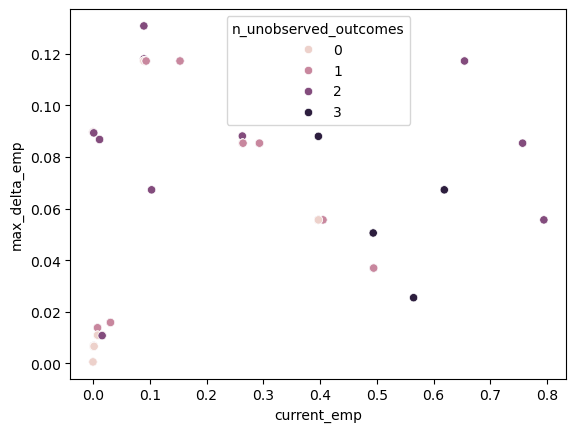

In [164]:
## find the cases where the certaintist has the highest expected gain in empowerment
tmp = df_cleaned.loc[
    (df_cleaned['ell']==10) 
               &(df_cleaned['t']==6)
]

## order tmp by max_delta_emp
tmp = tmp.sort_values('max_delta_emp', 
                    #   ascending=True
                      ascending=False
                      )
display(tmp[
    ['t','history_canon_counts_str','canon_p_0','canon_p_1','p_terminate', 'p_choose_least_sampled','current_emp','max_delta_emp', 'total_entropy', 'n_untried_arms', 'n_unobserved_outcomes']
].head(50))
print(len(tmp))

## scatter of current_emp and p_terminate
plt.figure()
# hue = 'n_untried_arms'
# # hue = 'n_unobserved_outcomes'
# sns.swarmplot(data=tmp,x = 'n_untried_arms', y = 'max_delta_emp', hue = 'n_unobserved_outcomes')

sns.scatterplot(data=tmp, 
                # x='max_delta_emp', 
                # y='p_terminate',
                x='current_emp', 
                y='max_delta_emp',
                # y='p_choose_least_sampled',

                # style='n_untried_arms',
                # hue = 'n_unobserved_outcomes',

                  hue = hue
                  )

## Find tipping points

### Run

In [ ]:
## init
n_arms = 2
n_outcomes = 4
n_trials = 6
alpha = 0.1
temp = 0.1
n_ell_samples = 1000
n_check_samples = 100
eps_tie = 1e-8

df_tip = enumerate_tipping_intervals(
    n_arms=n_arms, n_outcomes=n_outcomes, n_trials=n_trials,
    alpha=alpha, termination_arm=True, n_ell_samples=n_ell_samples, n_check_samples=n_check_samples, eps_tie=eps_tie,
    n_jobs=-1,
)

display(df_tip.head(50))

*** TIE VIOLATION: history=a0o0:2, lo=0.001, hi=100, ell=1.151395399326448, arm=0, Q=[1.59144837 1.59249176 1.46550057]
*** TIE VIOLATION: history=a0o0:2, lo=0.001, hi=100, ell=1.4563484775012443, arm=0, Q=[1.4771161  1.47829765 1.2216657 ]
*** TIE VIOLATION: history=a0o0:2, lo=0.001, hi=100, ell=1.8420699693267164, arm=0, Q=[1.37495641 1.37633692 1.0153337 ]
*** TIE VIOLATION: history=a0o0:2, lo=0.001, hi=100, ell=2.329951810515372, arm=0, Q=[1.27496804 1.27648853 0.85129731]
*** TIE VIOLATION: history=a0o0:2, lo=0.001, hi=100, ell=2.9470517025518097, arm=0, Q=[1.17309696 1.1742062  0.72512032]
*** TIE VIOLATION: history=a0o0:2, lo=0.001, hi=100, ell=3.7275937203149416, arm=0, Q=[1.06750005 1.06767981 0.62499209]


,history_str,t,arm,ell_lo,ell_hi,interval_idx,has_ties
0,init,0,0,0.001000,100.000000,0,True
1,init,0,1,0.001000,100.000000,0,True
2,a0o0:1,1,0,0.001000,100.000000,0,True
3,a0o0:1,1,1,1.000000,16.267277,0,True
4,a0o0:2,2,0,0.001000,100.000000,0,True
5,a0o0:2,2,1,1.053404,16.267277,0,True
6,a0o0:1-a0o1:1,2,2,0.001000,0.199008,0,False
7,a0o0:1-a0o1:1,2,0,0.199008,0.735461,0,False
8,a0o0:1-a0o1:1,2,1,0.735461,100.000000,0,False
9,a0o0:1-a1o0:1,2,0,0.001000,100.000000,0,True


### Plot histories

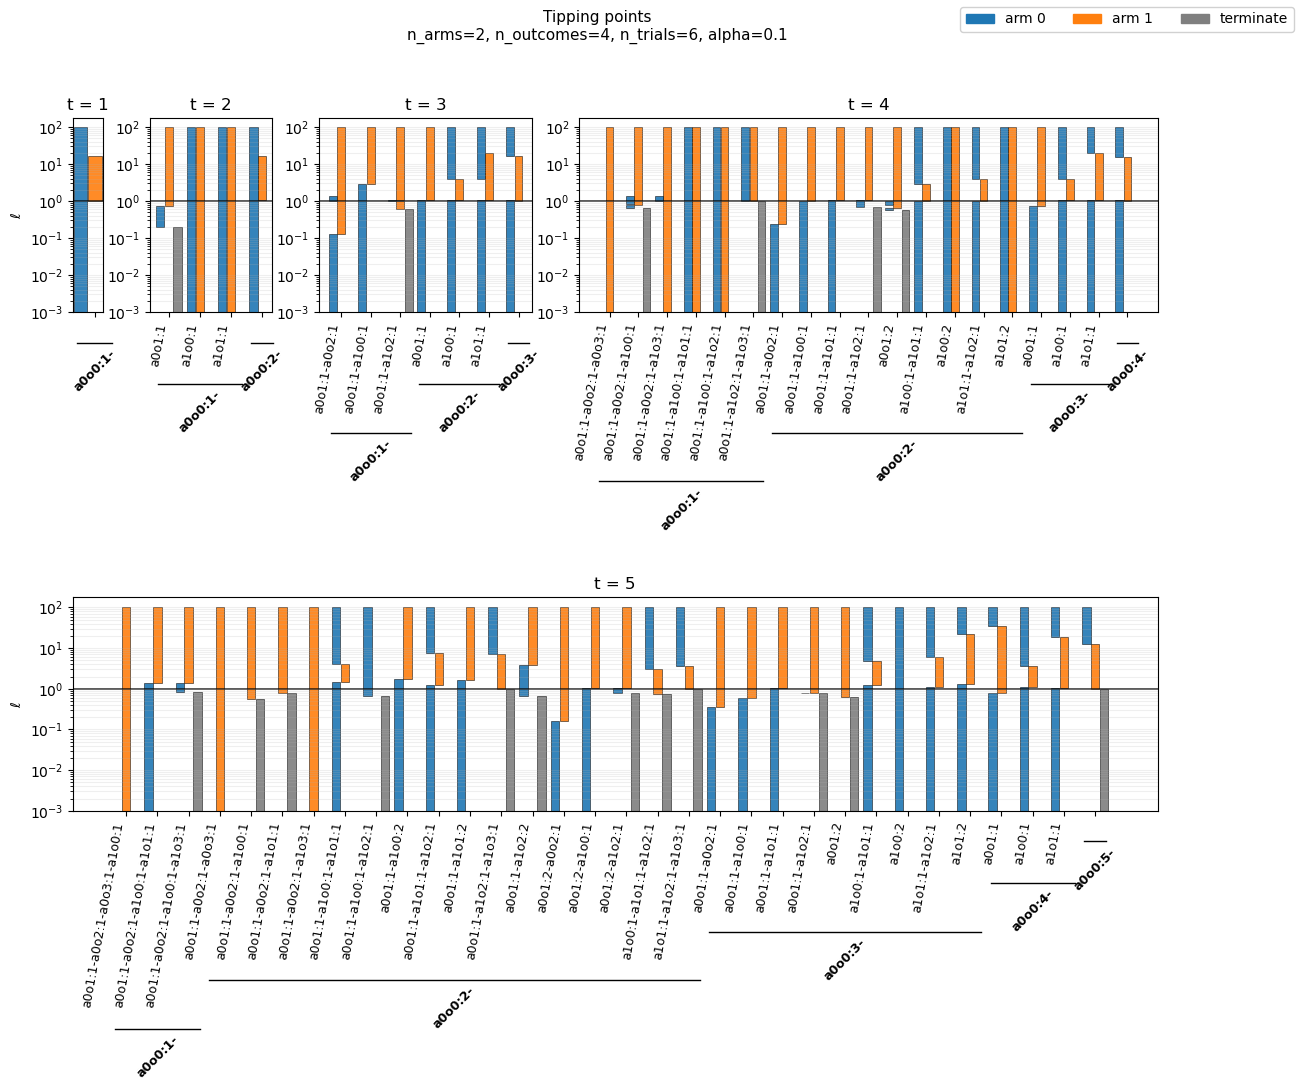

In [97]:
## plot
title = 'Tipping points\nn_arms={}, n_outcomes={}, n_trials={}, alpha={}'.format(n_arms, n_outcomes, n_trials, alpha)
plot_tipping_points(
    df_tip,
    n_arms=n_arms,
    n_plot_trials=6,
    group_brackets=True,
    skip_t0=True,
    legend=True,
    suptitle=f'{title}',
    log_scale=True
)
plt.show()

### Plot curves per history

In [99]:
n_arms = 2
n_outcomes = 4
n_trials = 6
n_ell_samples = 500
ell_lo = 0.01
ell_hi = 100
# alphas = [1]
# alphas = [0.1,]
alphas = np.linspace(0.01,1,8)
n_alpha_samples = 5
termination_arm = False
df_curves = enumerate_curves(n_arms=n_arms, n_outcomes=n_outcomes, n_trials=n_trials, alphas=alphas,
                             ell_hi=ell_hi, ell_lo=ell_lo,
                             termination_arm=termination_arm,
                        #      df_tip=df_tip, 
                             n_jobs=-1, n_ell_samples=n_ell_samples
                             )

Enumerating curves (alpha=0.01):   0%|          | 0/64 [00:00<?, ?it/s]

Enumerating curves (alpha=0.151):   0%|          | 0/64 [00:00<?, ?it/s]

Enumerating curves (alpha=0.293):   0%|          | 0/64 [00:00<?, ?it/s]

Enumerating curves (alpha=0.434):   0%|          | 0/64 [00:00<?, ?it/s]

Enumerating curves (alpha=0.576):   0%|          | 0/64 [00:00<?, ?it/s]

Enumerating curves (alpha=0.717):   0%|          | 0/64 [00:00<?, ?it/s]

Enumerating curves (alpha=0.859):   0%|          | 0/64 [00:00<?, ?it/s]

Enumerating curves (alpha=1):   0%|          | 0/64 [00:00<?, ?it/s]

In [109]:
df_curves.head(5100)

,alpha,history_str,t,ell,info_best_a,Q_0,p_0,info_Q_0,info_p_0,Q_1,p_1,info_Q_1,info_p_1
0,0.01,init,0,0.010000,0,3.958557,0.500000,0.017184,0.5,3.958557,0.500000,0.017184,0.5
1,0.01,init,0,0.010186,0,3.957790,0.500000,0.017184,0.5,3.957790,0.500000,0.017184,0.5
2,0.01,init,0,0.010376,0,3.957009,0.500000,0.017184,0.5,3.957009,0.500000,0.017184,0.5
3,0.01,init,0,0.010569,0,3.956214,0.500000,0.017184,0.5,3.956214,0.500000,0.017184,0.5
4,0.01,init,0,0.010766,0,3.955405,0.500000,0.017184,0.5,3.955405,0.500000,0.017184,0.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5095,0.01,a0o0:1-a0o1:1-a0o2:1,3,0.057746,1,3.744753,0.664099,0.127596,0.5,3.676592,0.335901,0.127596,0.5
5096,0.01,a0o0:1-a0o1:1-a0o2:1,3,0.058822,1,3.740169,0.666134,0.127596,0.5,3.671094,0.333866,0.127596,0.5
5097,0.01,a0o0:1-a0o1:1-a0o2:1,3,0.059918,1,3.735505,0.668174,0.127596,0.5,3.665511,0.331826,0.127596,0.5
5098,0.01,a0o0:1-a0o1:1-a0o2:1,3,0.061034,1,3.730761,0.670219,0.127596,0.5,3.659843,0.329781,0.127596,0.5


In [121]:
df_curves['p_1'].max()

0.9998224226238777

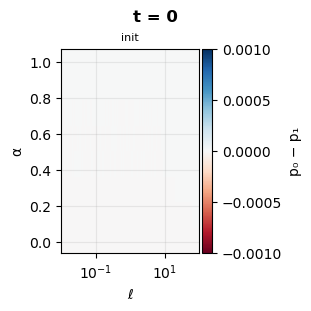

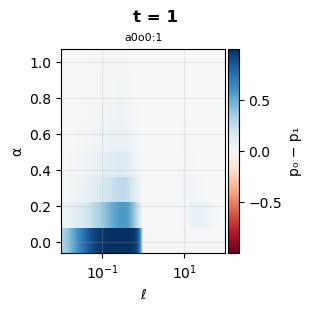

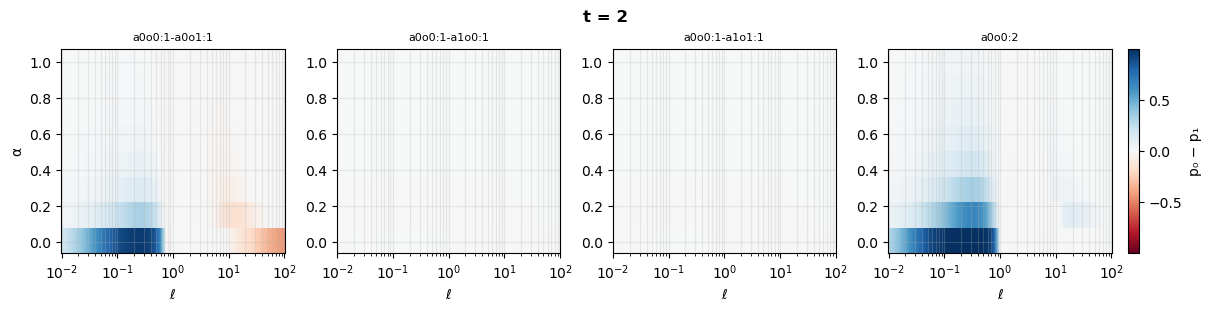

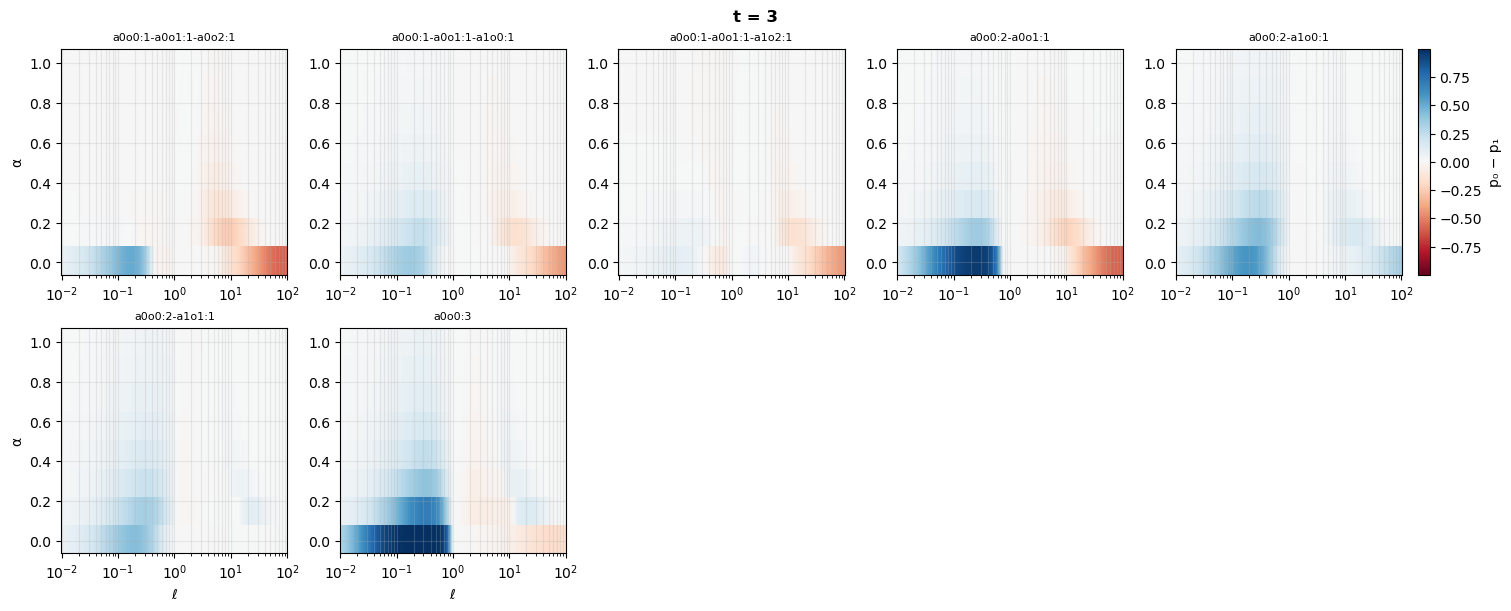

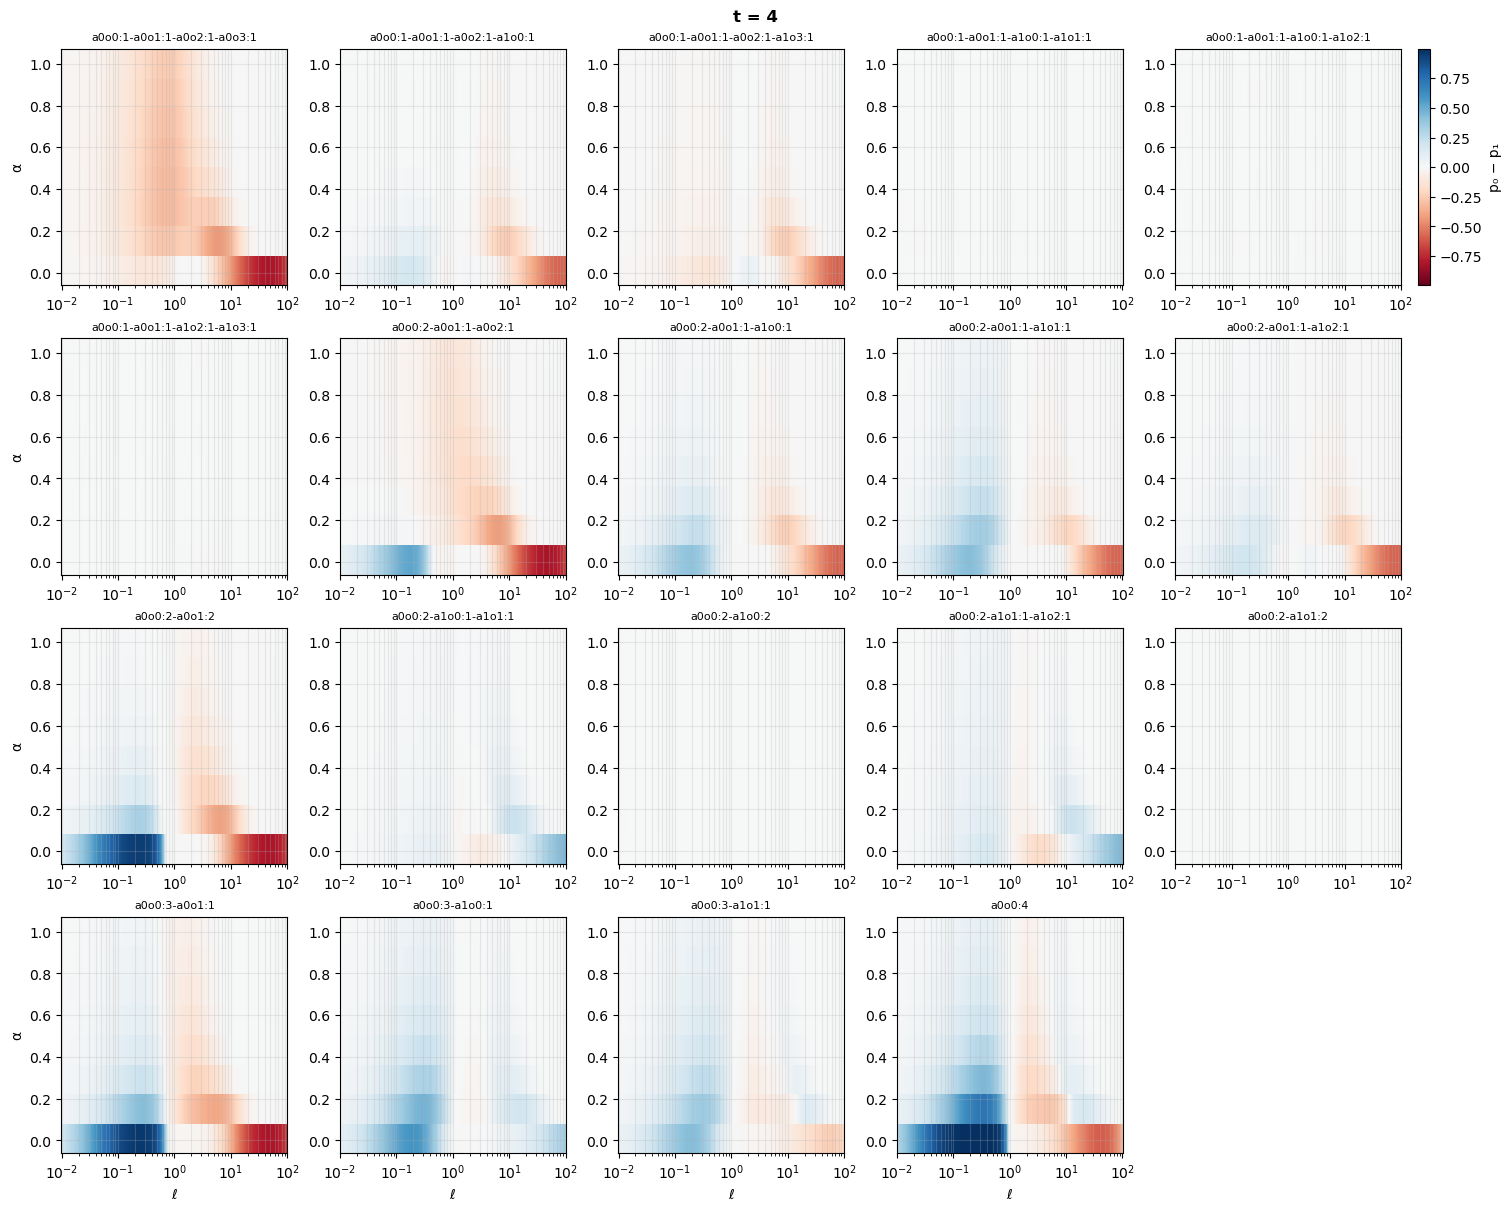

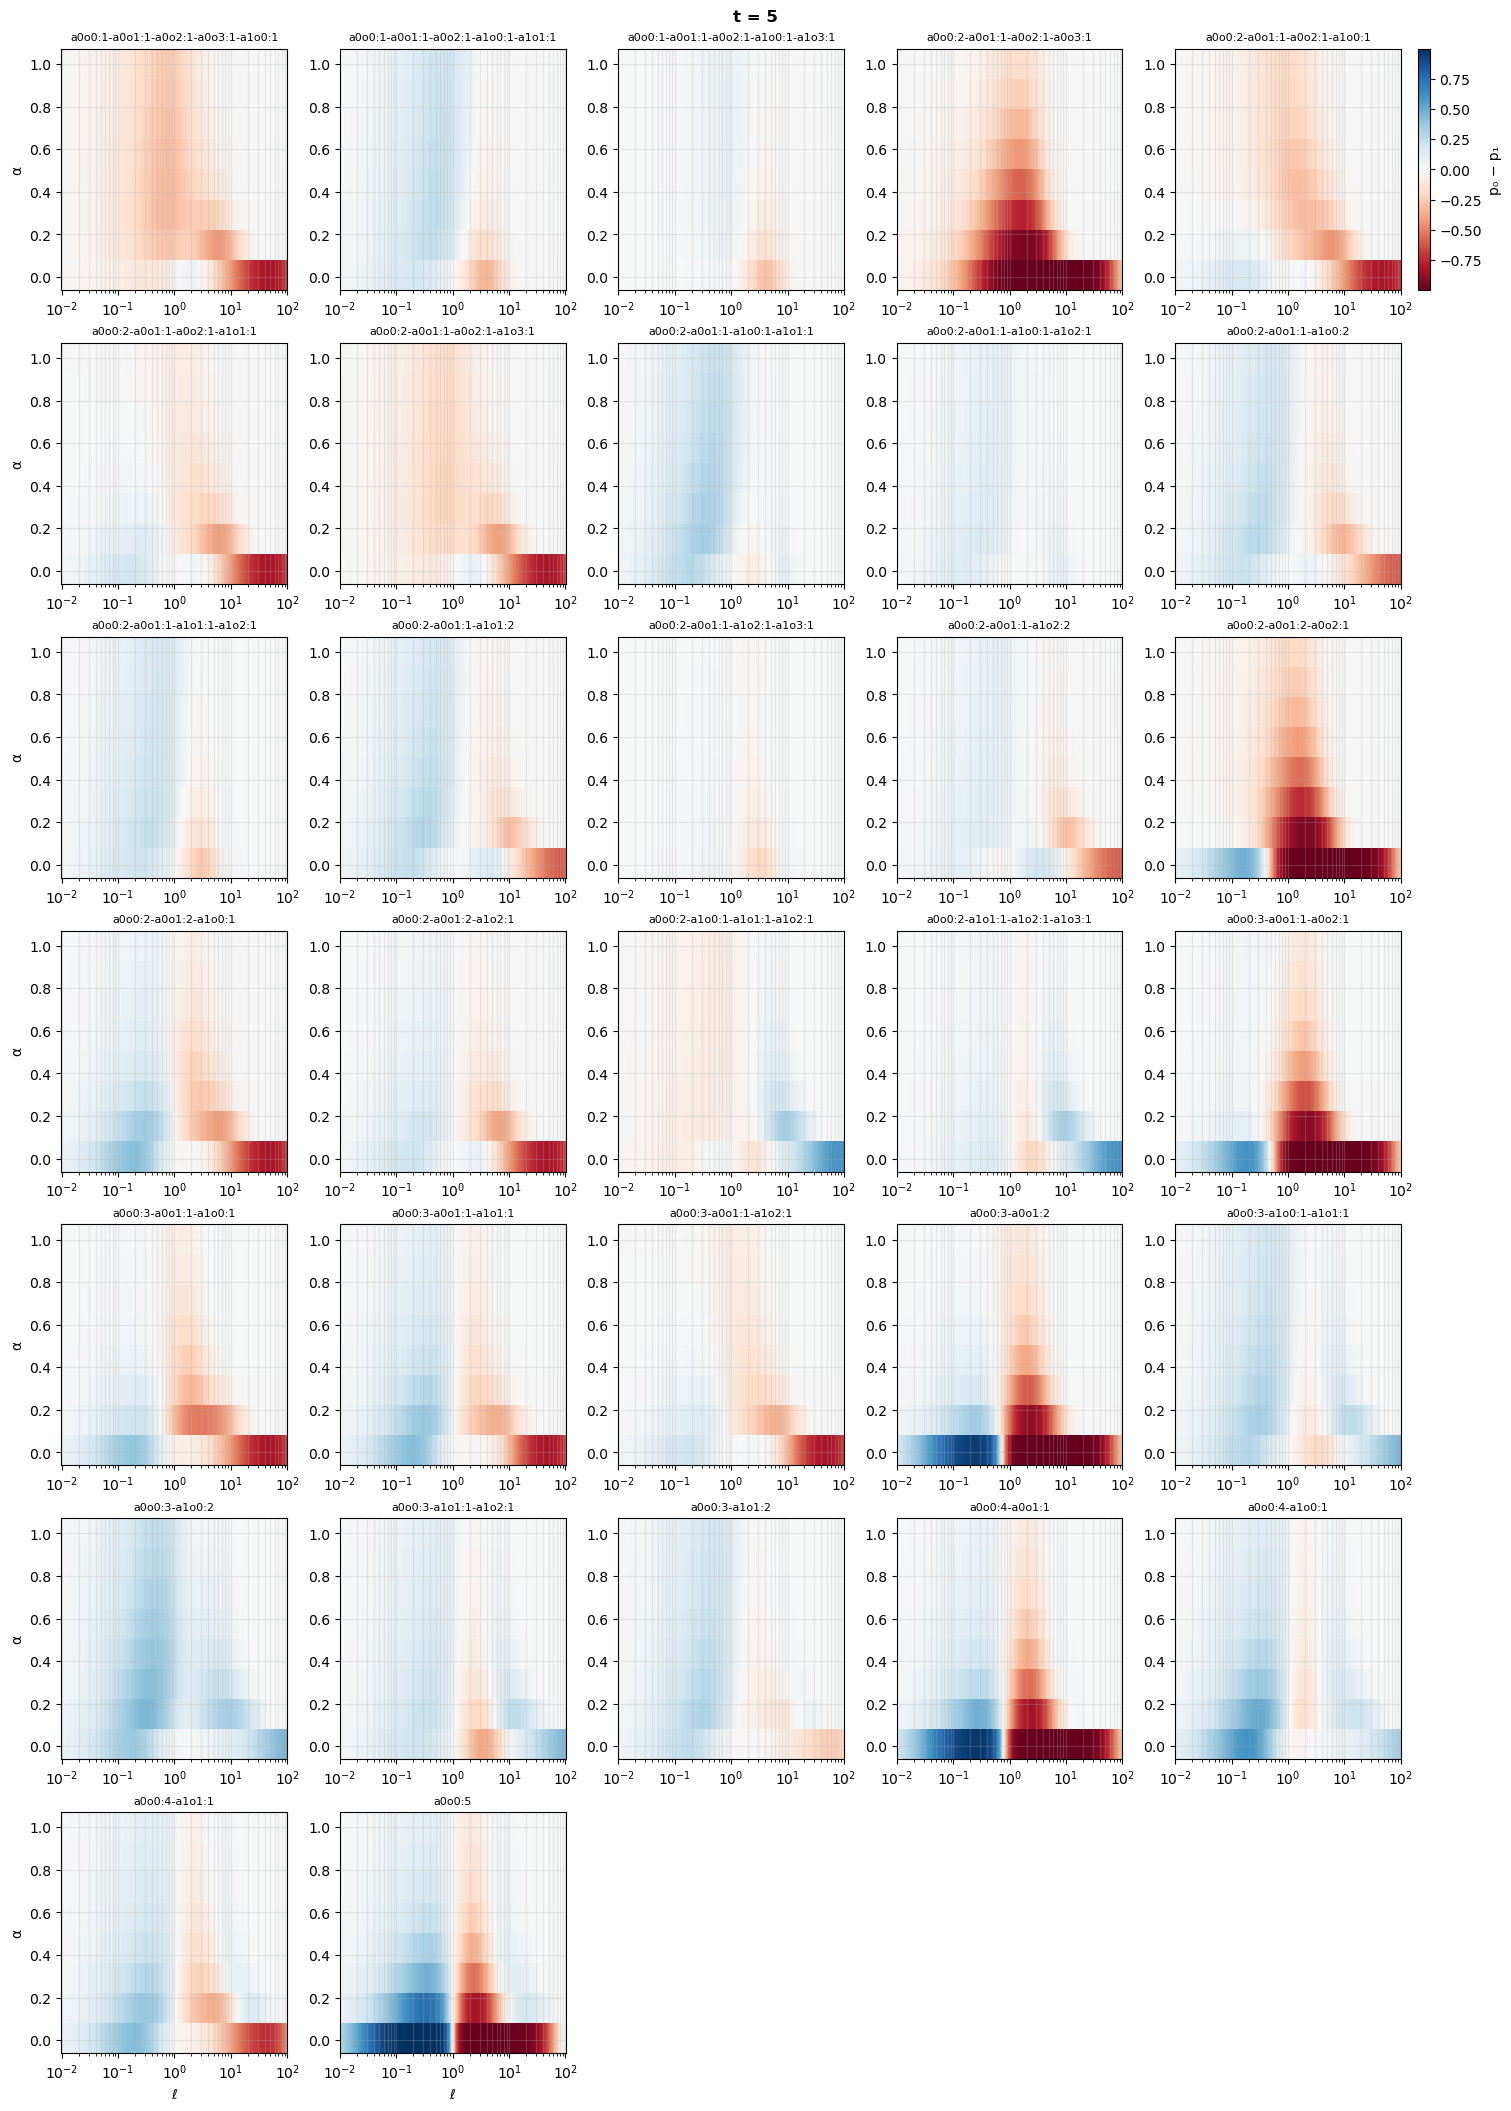

In [112]:
## plots
if n_alpha_samples == 1:
    figs = plot_curves(df_curves, n_arms=n_arms, y='p',
                eps_tie=1e-6,
                termination_arm=termination_arm,
            #    df_tip=df_tip
            ncols = 7
            )
else:
    figs = plot_heatmap(df_curves,
                        panel_size=(3,3),
        #    df_tip=df_tip
        max_n_cols = 5
           )

# ## save figs 
# fig_dir = f'useful_saves/ell_curves/{n_trials}trials_{n_arms}arms_{n_outcomes}outcomes'
# if not os.path.exists(fig_dir):
#     os.makedirs(fig_dir)
# for t, (fig, _) in figs.items():
#     fig.savefig(f'{fig_dir}/t{t}.png', dpi=300)

## Misc

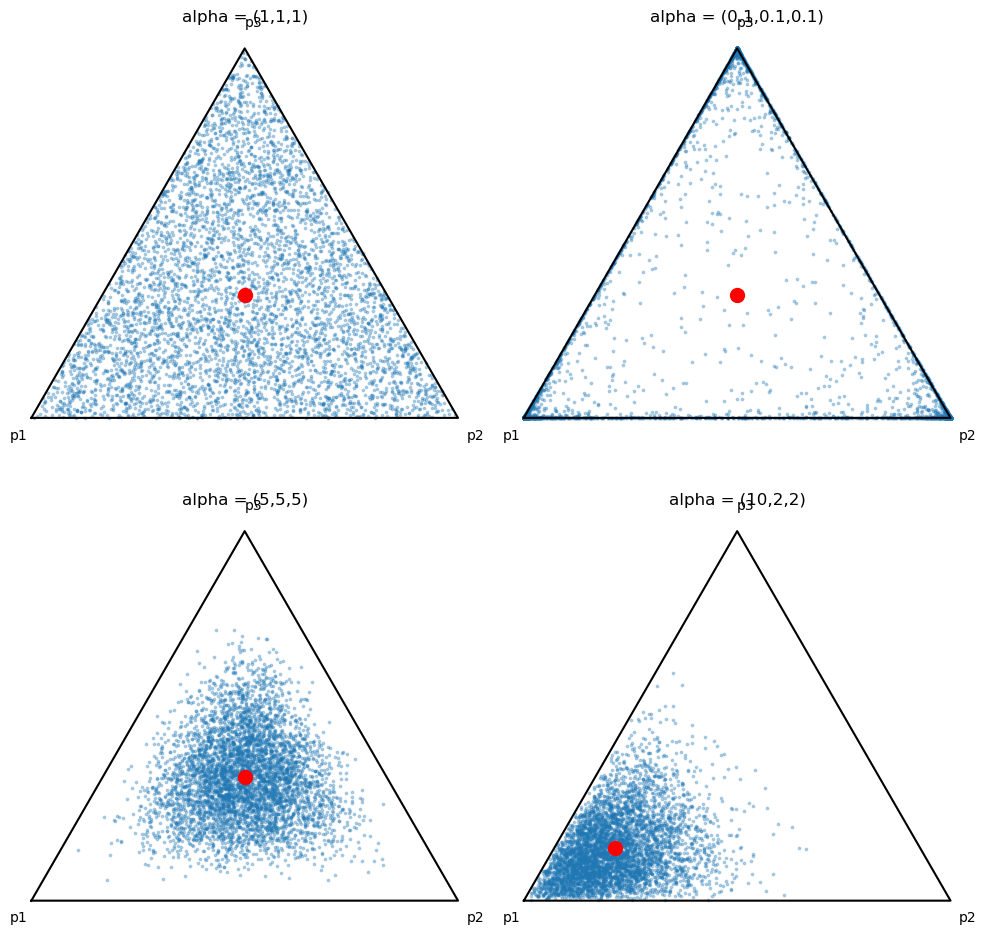

In [109]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Simplex projection utilities
# -----------------------------

def simplex_to_2d(p):
    """
    Convert 3D simplex coordinates (p1,p2,p3)
    into 2D Cartesian coordinates.
    """
    v1 = np.array([0, 0])
    v2 = np.array([1, 0])
    v3 = np.array([0.5, np.sqrt(3)/2])

    return (
        p[:, 0][:, None] * v1
        + p[:, 1][:, None] * v2
        + p[:, 2][:, None] * v3
    )

def draw_simplex(ax):
    triangle = np.array([
        [0, 0],
        [1, 0],
        [0.5, np.sqrt(3)/2],
        [0, 0]
    ])

    ax.plot(triangle[:, 0], triangle[:, 1], 'k-')

    ax.text(-0.05, -0.05, "p1")
    ax.text(1.02, -0.05, "p2")
    ax.text(0.5, np.sqrt(3)/2 + 0.05, "p3")

    ax.set_aspect('equal')
    ax.axis('off')

# -----------------------------
# Dirichlet priors to compare
# -----------------------------

priors = [
    ([1, 1, 1], "alpha = (1,1,1)"),
    ([0.1, 0.1, 0.1], "alpha = (0.1,0.1,0.1)"),
    ([5, 5, 5], "alpha = (5,5,5)"),
    ([10, 2, 2], "alpha = (10,2,2)")
]

# -----------------------------
# Plot
# -----------------------------

fig, axes = plt.subplots(2, 2, figsize=(10, 10))

for ax, (alpha, title) in zip(axes.flatten(), priors):

    samples = np.random.dirichlet(alpha, size=5000)
    xy = simplex_to_2d(samples)

    draw_simplex(ax)

    ax.scatter(
        xy[:, 0],
        xy[:, 1],
        s=3,
        alpha=0.3
    )

    ## plot mean
    mean = np.array(alpha) / np.sum(alpha)
    mean_xy = simplex_to_2d(mean[None, :])
    ax.scatter(
        mean_xy[:, 0],
        mean_xy[:, 1],
        s=100,
        color='red',
    )

    ax.set_title(title)

plt.tight_layout()
plt.show()

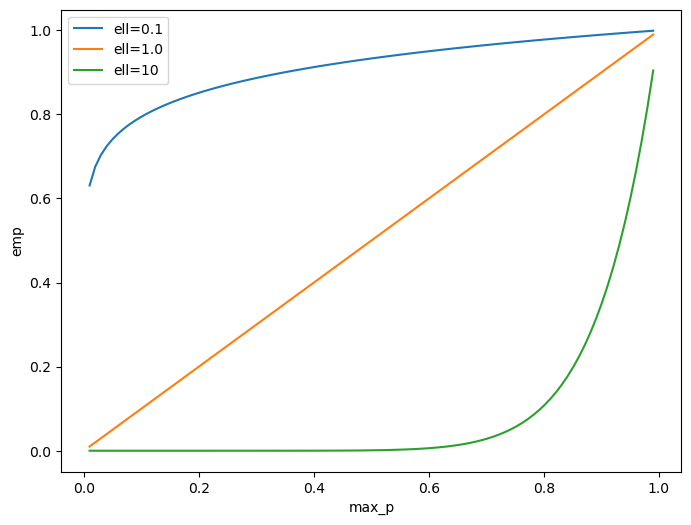

In [16]:
ells = [0.1, 1.0, 10]
x = np.linspace(0.01, 0.99, 100)
plt.figure(figsize=(8, 6))
for ell in ells:
    plt.plot(x, x**ell, label=f'ell={ell}')
plt.xlabel('max_p')
plt.ylabel('emp')
plt.legend()

a0 init: 0, Prior mean: [0.33333333 0.33333333 0.33333333]
Shift in all means after observing outcome 0: [ 0.16666667 -0.08333333 -0.08333333]
Shift in all means after observing outcome 1: [-0.08333333  0.16666667 -0.08333333]
Shift in all means after observing outcome 2: [-0.08333333 -0.08333333  0.16666667]

a0 init: 1, Prior mean: [0.5  0.25 0.25]
Shift in all means after observing outcome 0: [ 0.1  -0.05 -0.05]
Shift in all means after observing outcome 1: [-0.1   0.15 -0.05]
Shift in all means after observing outcome 2: [-0.1  -0.05  0.15]

a0 init: 2, Prior mean: [0.6 0.2 0.2]
Shift in all means after observing outcome 0: [ 0.06666667 -0.03333333 -0.03333333]
Shift in all means after observing outcome 1: [-0.1         0.13333333 -0.03333333]
Shift in all means after observing outcome 2: [-0.1        -0.03333333  0.13333333]

a0 init: 3, Prior mean: [0.66666667 0.16666667 0.16666667]
Shift in all means after observing outcome 0: [ 0.04761905 -0.02380952 -0.02380952]
Shift in all m

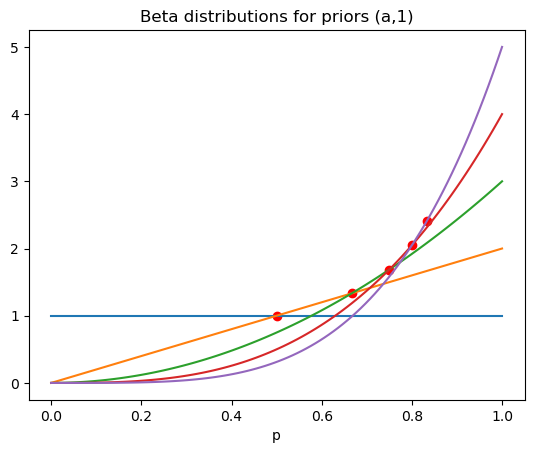

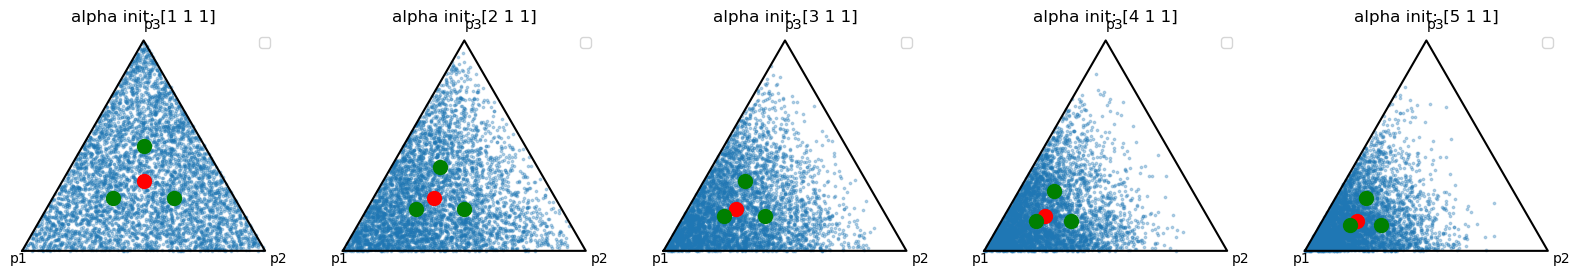

In [48]:
## plot beta distributions for priors (a,1) where a increments from 1 to 5
plt.figure()
for a in range(1, 6):
    x = np.linspace(0, 1, 100)
    y = stats.beta.pdf(x, a, 1)
    plt.plot(x, y, label=f'a={a}')
    mean = a / (a + 1)
    plt.scatter(mean, stats.beta.pdf(mean, a, 1), label=f'mean a={a}', color='red')
plt.title('Beta distributions for priors (a,1)')
plt.xlabel('p')

## now, let's loop through dirichlet priors (a,1,1) where a increments from 1 to 5
# for a in range(1, 6):
#     alpha = [a, 1, 1]
#     samples = np.random.dirichlet(alpha, size=5000)
#     xy = simplex_to_2d(samples)

#     plt.figure()
#     draw_simplex(plt.gca())
#     plt.scatter(
#         xy[:, 0],
#         xy[:, 1],
#         s=3,
#         alpha=0.3
#     )

#     ## plot mean
#     mean = np.array(alpha) / np.sum(alpha)
#     mean_xy = simplex_to_2d(mean[None, :])
#     plt.scatter(
#         mean_xy[:, 0],
#         mean_xy[:, 1],
#         s=100,
#         color='red',
#     )

#     plt.title(f'Dirichlet samples for alpha={alpha}')


## for dirichlet prior (5,1,1), calculate the shift in posterior mean after observing one sample of each outcome (i.e., adding 1 to each alpha)
n_a0_inits = 5
a = 1

fig, axs = plt.subplots(1, n_a0_inits, figsize=(20, 4))
for a0_init in range(0, n_a0_inits):
    alpha = np.array([a0_init+a, a, a])
    mean_prior = alpha / np.sum(alpha)
    print(f"a0 init: {a0_init}, Prior mean: {mean_prior}")
    samples = np.random.dirichlet(alpha, size=5000)
    xy = simplex_to_2d(samples)
    draw_simplex(axs[a0_init])
    axs[a0_init].scatter(
        xy[:, 0],
        xy[:, 1],
        s=3,
        alpha=0.3
    )
    #mean
    mean_xy = simplex_to_2d(mean_prior[None, :])
    axs[a0_init].scatter(
        mean_xy[:, 0],
        mean_xy[:, 1],
        s=100,
        color='red',
    )
    axs[a0_init].set_title(f"alpha init: {alpha}")
    for k in range(3):
        alpha_post = alpha + np.eye(3)[k]  # add one sample to the k-th outcome
        mean_post = alpha_post / np.sum(alpha_post)
        # print(f"Posterior mean over: {mean_post} after observing outcome {k+1}")
        # print('Shift in mean over outcomes: {:.3f}'.format(mean_post[0] - mean_prior[0]))
        mean_shifts = mean_post - mean_prior
        print('Shift in all means after observing outcome {}: {}'.format(k, mean_shifts))
        # print('Shift in mean over outcomes: {:.3f}'.format(np.linalg.norm(mean_post - mean_prior)))
        samples_post = np.random.dirichlet(alpha_post, size=5000)
        # xy_post = simplex_to_2d(samples_post)
        # axs[a0_init].scatter(
        #     xy_post[:, 0],
        #     xy_post[:, 1],
        #     s=3,
        #     alpha=0.2,
        #     # label=f'obs outcome {k+1}'
        # )
        # plot mean of posterior
        mean_post_xy = simplex_to_2d(mean_post[None, :])
        axs[a0_init].scatter(
            mean_post_xy[:, 0],
            mean_post_xy[:, 1],
            s=100,
            color='green',
            # label=f'mean post obs outcome {k+1}'
        )
    axs[a0_init].legend()
    print()
